<a href="https://colab.research.google.com/github/nitindavegit/Deep-Learning/blob/main/pytorch04_NeuralNetwork_Module.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Create a modal class
import torch
import torch.nn as nn

class Model(nn.Module):

  def __init__(self, num_features):

    super().__init__()
    self.linear = nn.Linear(num_features, 1)   # Create a single nueron
    self.sigmoid = nn.Sigmoid()  # Activation function

  def forward(self, features):
    out = self.linear(features)   # z = w*x + b
    out =  self.sigmoid(out)      # applying activation function on z
    return out

In [2]:
# create a dataset
features = torch.rand(10,5)
print(features)

# create a model
model = Model(features.shape[1])

# call model for a forward pass
# model.forward(features)    can be used but we will use below method because of magic function
model(features)


tensor([[0.3309, 0.9638, 0.1969, 0.2407, 0.4153],
        [0.2056, 0.7345, 0.7221, 0.9653, 0.4508],
        [0.6414, 0.1496, 0.8266, 0.5645, 0.3439],
        [0.1796, 0.3383, 0.6793, 0.8898, 0.7295],
        [0.9640, 0.5022, 0.5236, 0.8166, 0.9747],
        [0.1509, 0.2301, 0.5454, 0.3956, 0.3745],
        [0.3061, 0.8308, 0.1810, 0.8558, 0.0859],
        [0.6164, 0.9070, 0.1969, 0.5086, 0.8819],
        [0.4180, 0.9044, 0.2752, 0.3041, 0.7868],
        [0.7206, 0.2541, 0.9429, 0.0543, 0.5688]])


tensor([[0.6407],
        [0.6287],
        [0.6298],
        [0.6472],
        [0.7394],
        [0.5975],
        [0.6242],
        [0.7150],
        [0.6813],
        [0.6391]], grad_fn=<SigmoidBackward0>)

In [3]:
model.linear.weight

Parameter containing:
tensor([[ 0.3817,  0.0675, -0.1978,  0.1382,  0.4272]], requires_grad=True)

In [4]:
model.linear.bias

Parameter containing:
tensor([0.2152], requires_grad=True)

In [5]:
!pip install torchinfo

In [6]:
from torchinfo import summary
summary(model, input_size=(10,5))

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [10, 1]                   --
├─Linear: 1-1                            [10, 1]                   6
├─Sigmoid: 1-2                           [10, 1]                   --
Total params: 6
Trainable params: 6
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

Create a NN who have 3 hidden neuron as layer and 1 output neuron

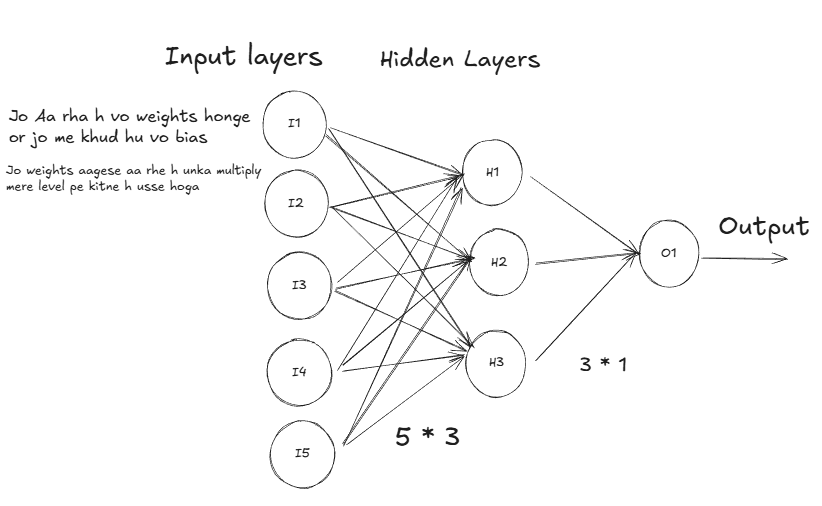

In [7]:
import torch
import torch.nn as nn

class Model(nn.Module):

  def __init__(self, num_features):   # passing input
    super().__init__()
    self.linear1 = nn.Linear(num_features, 3) # hidden layer
    self.relu = nn.ReLU()

    self.linear2 = nn.Linear(3,1)  # output layer
    self.sigmoid = nn.Sigmoid()

  def forward(self, features):
    out1 = self.linear1(features)
    out1 = self.relu(out1)

    out2 = self.linear2(out1)
    out2 = self.sigmoid(out2)

    return out2

In [8]:
features = torch.rand(10,5)
model = Model(features.shape[1])
model(features)

tensor([[0.6001],
        [0.5864],
        [0.5864],
        [0.5864],
        [0.6032],
        [0.5864],
        [0.5873],
        [0.5904],
        [0.5902],
        [0.5851]], grad_fn=<SigmoidBackward0>)

In [9]:
model.linear1.weight

Parameter containing:
tensor([[ 0.1591, -0.1432, -0.2228,  0.3940, -0.1315],
        [ 0.0658, -0.2462,  0.3643,  0.0226,  0.0334],
        [ 0.0168, -0.3622, -0.3680,  0.3153,  0.0371]], requires_grad=True)

In [10]:
from torchinfo import summary
summary(model, input_size=features.shape)

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [10, 1]                   --
├─Linear: 1-1                            [10, 3]                   18
├─ReLU: 1-2                              [10, 3]                   --
├─Linear: 1-3                            [10, 1]                   4
├─Sigmoid: 1-4                           [10, 1]                   --
Total params: 22
Trainable params: 22
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

Use of containers

With this new neural network

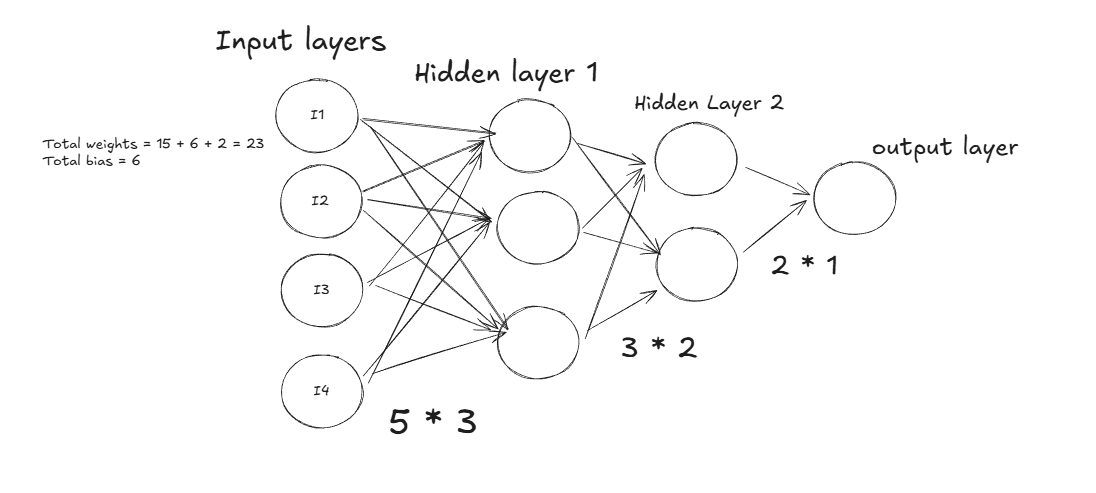

### Use of sequential

In [11]:
import torch
import torch.nn as nn

class Model(nn.Module):

  def __init__(self, num_features):
    super().__init__()
    self.network = nn.Sequential(
        nn.Linear(num_features, 3),
        nn.ReLU(),
        nn.Linear(3, 2),
        nn.ReLU(),
        nn.Linear(2,1),
        nn.Sigmoid()
    )

  def forward(self, features):
    out = self.network(features)
    return out

In [12]:
features = torch.rand(6,4)
model = Model(features.shape[1])
model(features)

tensor([[0.4105],
        [0.4105],
        [0.4105],
        [0.4105],
        [0.4105],
        [0.4105]], grad_fn=<SigmoidBackward0>)